# KNN for Regression

In [4]:
import mglearn 
import matplotlib.pyplot as plt

/lib/python3.13/site-packages/mglearn/datasets.py:37: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [3]:
%pip install mglearn

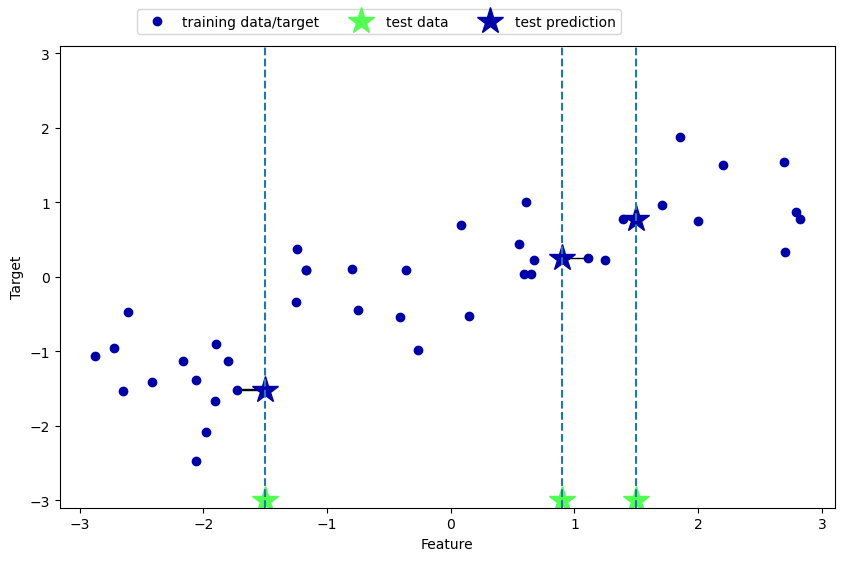

In [5]:
mglearn.plots.plot_knn_regression(n_neighbors=1)

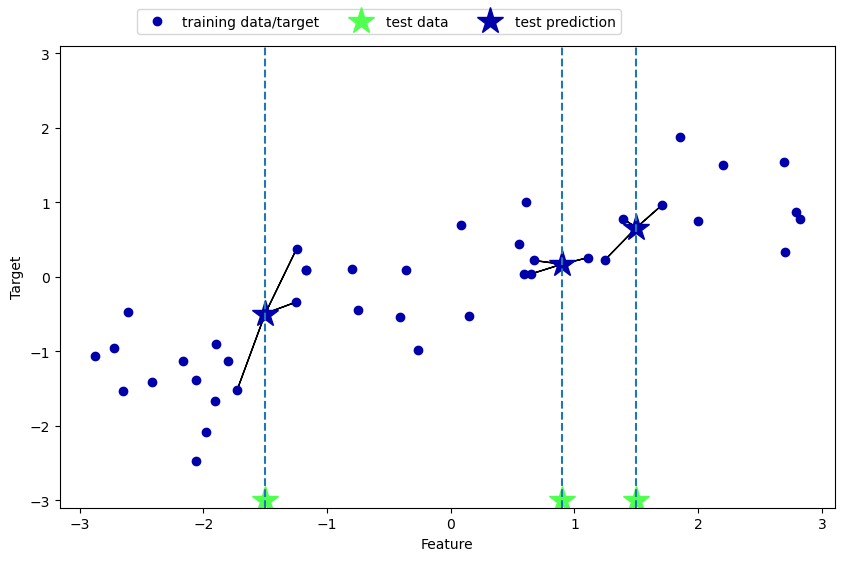

In [7]:
mglearn.plots.plot_knn_regression(n_neighbors=3)

In [6]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
X, y = mglearn.datasets.make_wave(n_samples=40)# split the wave dataset into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)# instantiate the model and set the number of neighbors to consider to 3
reg = KNeighborsRegressor(n_neighbors=3)# fit the model using the training data and training targets
reg.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [7]:
print(reg.score(X_test, y_test))

0.8344172446249605


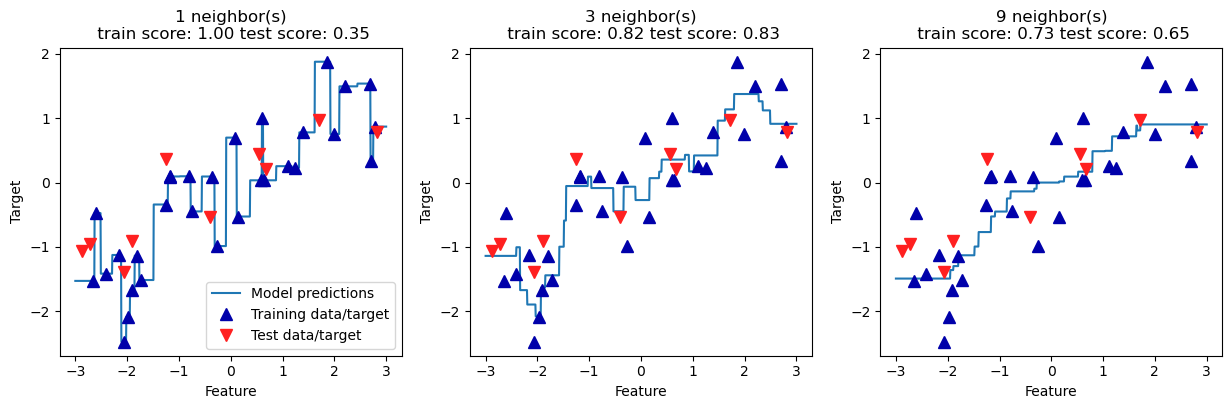

In [8]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# create 1,000 data points, evenly spaced between -3 and 3
line = np.linspace(-3, 3, 1000).reshape(-1, 1)
for n_neighbors, ax in zip([1, 3, 9], axes):
    # make predictions using 1, 3, or 9 neighbors
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)
    ax.plot(line, reg.predict(line))
    ax.plot(X_train, y_train, '^', c=mglearn.cm2(0),   
             markersize=8)
    ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)
    ax.set_title("{} neighbor(s)\n train score: {:.2f} test score: {:.2f}".format(n_neighbors,    
              reg.score(X_train, y_train),reg.score(X_test, 
              y_test)))
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")
    axes[0].legend(["Model predictions", "Training data/target","Test data/target"], loc="best")

Interesting parameters for KNR
<br>
1. weights : {'uniform', 'distance'}
2. metric : {'minkowski', 'euclidean', 'manhattan', 'chebyshev' ...}
3. p : int (minkowski distance power, default = 2)

For more information visit
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html

# Try to implement yourself

Hints and subtasks
1. You can use the same dataset (X, y)
2. You will need distance function
3. You will need to find K closest points to the given one. You may start with the simple implementation of this algorithm.
3. In the same graphic draw train and test scores when changing K parameter (First try to imagine how should this look?).

In [13]:
class KnnRegressor:
    def __init__(self, n_neighbors=5, metric='minkowski', p=2):
        self.n_neighbors = n_neighbors
        self.metric = metric
        self.p = p
        self.tree = None
        self.y_train = None
    
    def fit(self, x_train, y_train):
        self.x_train = np.array(x_train)
        self.y_train = np.array(y_train) #for broadcasting
    
    def predict(self, x_test):
        predictions = []
        for x in x_test:
            distances = np.sqrt(np.sum((self.x_train - x)**2, axis=1))
            indices = np.argsort(distances)[:self.n_neighbors]
            predictions.append(np.mean(self.y_train[indices]))
        return np.array(predictions)
        
    
    def score(self, x_test, y_test):
        y_pred = self.predict(x_test)
        u = np.sum((y_test - y_pred)**2)
        v = np.sum((y_test - np.mean(self.y_train))**2)
        return 1 - (u/v)

Let's check if the class works correctly. We will use the same code that is in the cell[6] to plot the results. 

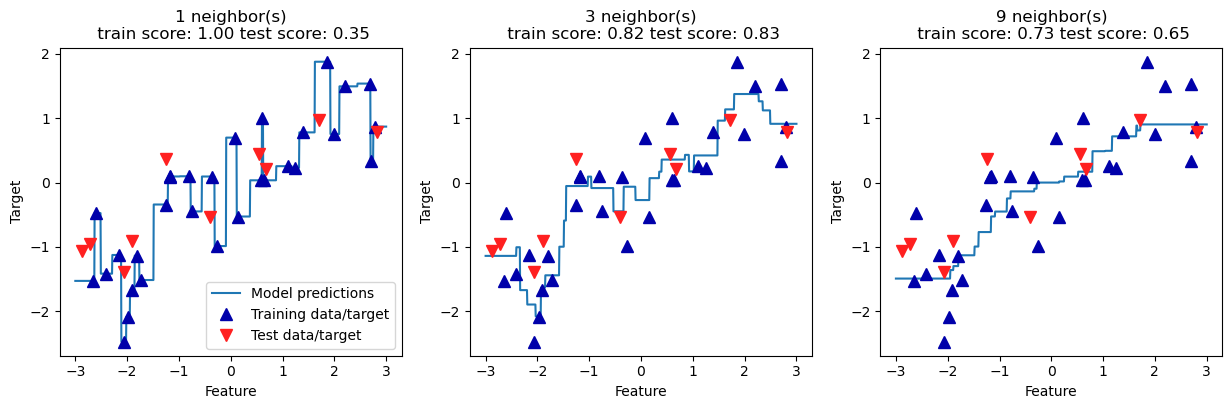

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
line = np.linspace(-3, 3, 1000).reshape(-1, 1)

for n_neighbors, ax in zip([1, 3, 9], axes):
    reg = KnnRegressor(n_neighbors=n_neighbors) #using the class written by me
    reg.fit(X_train, y_train)
    ax.plot(line, reg.predict(line))
    ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
    ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8)
    ax.set_title("{} neighbor(s)\n train score: {:.2f} test score: {:.2f}".format(n_neighbors,    
              reg.score(X_train, y_train),reg.score(X_test, y_test)))
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")
    axes[0].legend(["Model predictions", "Training data/target","Test data/target"], loc="best")

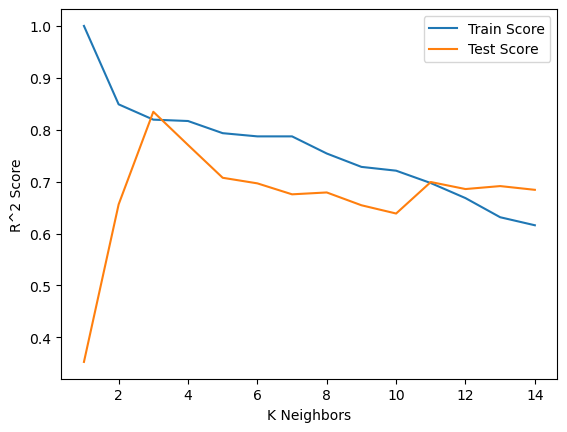

In [16]:
import matplotlib.pyplot as plt

k_range = range(1, 15)
train_scores = []
test_scores = []

for k in k_range:
    model = KnnRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.plot(k_range, train_scores, label="Train Score")
plt.plot(k_range, test_scores, label="Test Score")
plt.xlabel("K Neighbors")
plt.ylabel("R^2 Score")
plt.legend()
plt.show()